# US Accidents (2016 - 2023)
## A Countrywide Traffic Accident Dataset (2016 - 2023)

### SQL Project

In [107]:
#Installing libraries:

In [1]:
%pip install seaborn
%pip install plotly
%pip install nbformat

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [109]:
# Importing libraries:

In [2]:
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

file_path = "C:/Users/ivanp/.cache/kagglehub/datasets/sobhanmoosavi/us-accidents/versions/13/US_Accidents_March23.csv"


In [4]:
# Using DuckDB to handle big datasets with millions of rows like this (+ 7,000,000 rows)
df = duckdb.sql(f"""
SELECT *
FROM read_csv_auto('{file_path}')
LIMIT 5
""").df()

In [5]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,None,None,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,None,None,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,None,None,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,None,None,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,None,None,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [6]:
duckdb.sql(f"""
SELECT COUNT(*) AS total_rows
FROM read_csv_auto('{file_path}')
""").df()

,total_rows
0,7728394


In [7]:
# Describe the columns
duckdb.sql(f"""
DESCRIBE
SELECT *
FROM read_csv_auto('{file_path}')
""").df()

,column_name,column_type,null,key,default,extra
0,ID,VARCHAR,YES,None,None,None
1,Source,VARCHAR,YES,None,None,None
2,Severity,BIGINT,YES,None,None,None
3,Start_Time,TIMESTAMP,YES,None,None,None
4,End_Time,TIMESTAMP,YES,None,None,None
5,Start_Lat,DOUBLE,YES,None,None,None
6,Start_Lng,DOUBLE,YES,None,None,None
7,End_Lat,VARCHAR,YES,None,None,None
8,End_Lng,VARCHAR,YES,None,None,None
9,Distance(mi),DOUBLE,YES,None,None,None


In [8]:

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE TABLE accidents AS
SELECT *
FROM read_csv_auto('{file_path}')
""")

In [9]:
# Check NULL values per column
con.sql("""
SELECT 
    COUNT(*) AS total_rows,
    COUNT(Start_Time) AS start_time_not_null,
    COUNT(End_Time) AS end_time_not_null,
    COUNT(Weather_Condition) AS weather_not_null
FROM accidents
""").df()

,total_rows,start_time_not_null,end_time_not_null,weather_not_null
0,7728394,7728394,7728394,7554935


In [10]:
# Total Null Values
total_rows= 7728394
weather_not_null = 7554935
total_null = total_rows - weather_not_null
print(total_null)


173459


In [11]:
#  Accidents by State
duckdb.sql(f"""
SELECT State, COUNT(*) AS total_accidents
FROM read_csv_auto('{file_path}')
GROUP BY State
ORDER BY total_accidents DESC
LIMIT 10
""").df()

,State,total_accidents
0,CA,1741433
1,FL,880192
2,TX,582837
3,SC,382557
4,NY,347960
5,NC,338199
6,VA,303301
7,PA,296620
8,MN,192084
9,OR,179660


In [68]:
# California leading by far the total of accidents

In [12]:
df_acc_state = duckdb.sql(f"""
SELECT State, COUNT(*) AS total_accidents
FROM read_csv_auto('{file_path}')
GROUP BY State
ORDER BY total_accidents DESC
LIMIT 10
""").df()

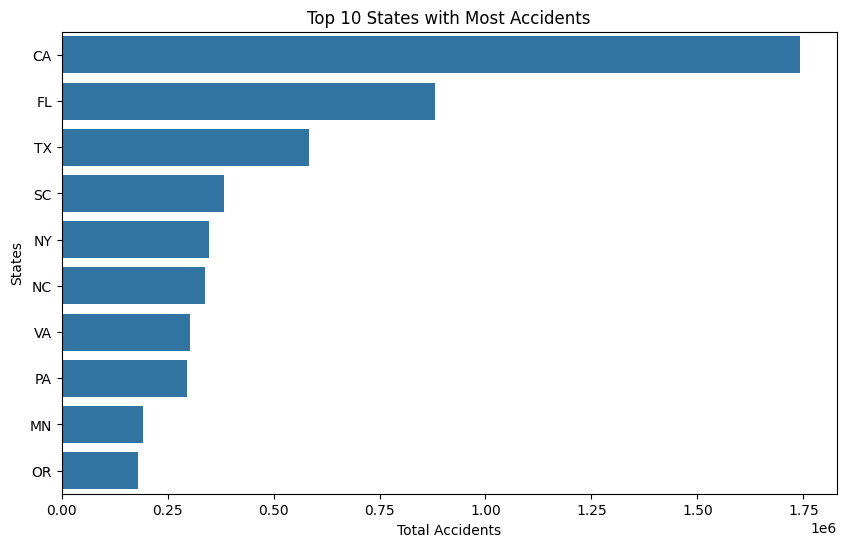

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_acc_state,
    x="total_accidents",
    y="State"
)

plt.title("Top 10 States with Most Accidents")
plt.xlabel("Total Accidents")
plt.ylabel("States")

plt.show()

In [14]:

fig = px.choropleth(
    df_acc_state, width=1000, height=600,
    locations="State",
    locationmode="USA-states",
    color="total_accidents",
    title="Top 10 States with Most Accidents",
    scope="usa"
)

fig.show()

In [15]:
# Accidents by City
duckdb.sql(f"""
SELECT City, State, COUNT(*) AS total_accidents
FROM read_csv_auto('{file_path}')
GROUP BY City, State
ORDER BY total_accidents DESC
LIMIT 10
""").df()

,City,State,total_accidents
0,Miami,FL,186768
1,Houston,TX,169428
2,Los Angeles,CA,156491
3,Charlotte,NC,138345
4,Dallas,TX,130303
5,Orlando,FL,109690
6,Austin,TX,96604
7,Raleigh,NC,86066
8,Nashville,TN,72670
9,Baton Rouge,LA,71588


In [16]:
# Accidents by City
df_acc_city=duckdb.sql(f"""
SELECT City, State, COUNT(*) AS total_accidents
FROM read_csv_auto('{file_path}')
GROUP BY City, State
ORDER BY total_accidents DESC
LIMIT 10
""").df()

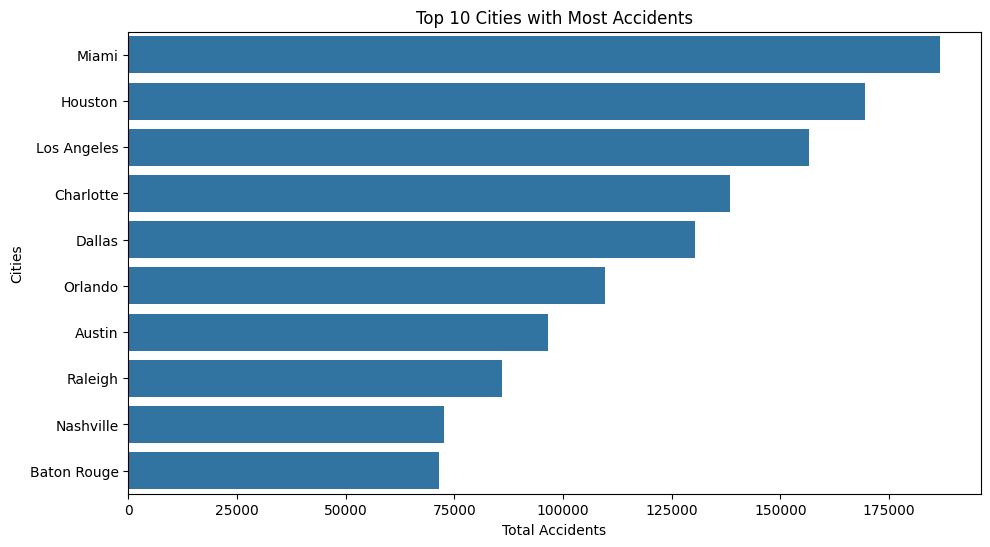

In [17]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=df_acc_city,
    x="total_accidents",
    y="City"
)

plt.title("Top 10 Cities with Most Accidents")
plt.xlabel("Total Accidents")
plt.ylabel("Cities")

plt.show()

In [18]:
# Weather Condition
# Now query with SQL

con.sql("""
SELECT Weather_Condition, COUNT(*) AS total_accidents
FROM accidents
WHERE Weather_Condition IS NOT NULL
GROUP BY Weather_Condition
ORDER BY total_accidents DESC
LIMIT 10
""").df()

,Weather_Condition,total_accidents
0,Fair,2560802
1,Mostly Cloudy,1016195
2,Cloudy,817082
3,Clear,808743
4,Partly Cloudy,698972
5,Overcast,382866
6,Light Rain,352957
7,Scattered Clouds,204829
8,Light Snow,128680
9,Fog,99238


In [70]:
# Total accidents in fair weather are 2.5 times higher than in moustly cloudy conditions

In [19]:
# Weather Condition

df_acc_weather=con.sql("""
SELECT Weather_Condition, COUNT(*) AS total_accidents
FROM accidents
WHERE Weather_Condition IS NOT NULL
GROUP BY Weather_Condition
ORDER BY total_accidents DESC
LIMIT 10
""").df()

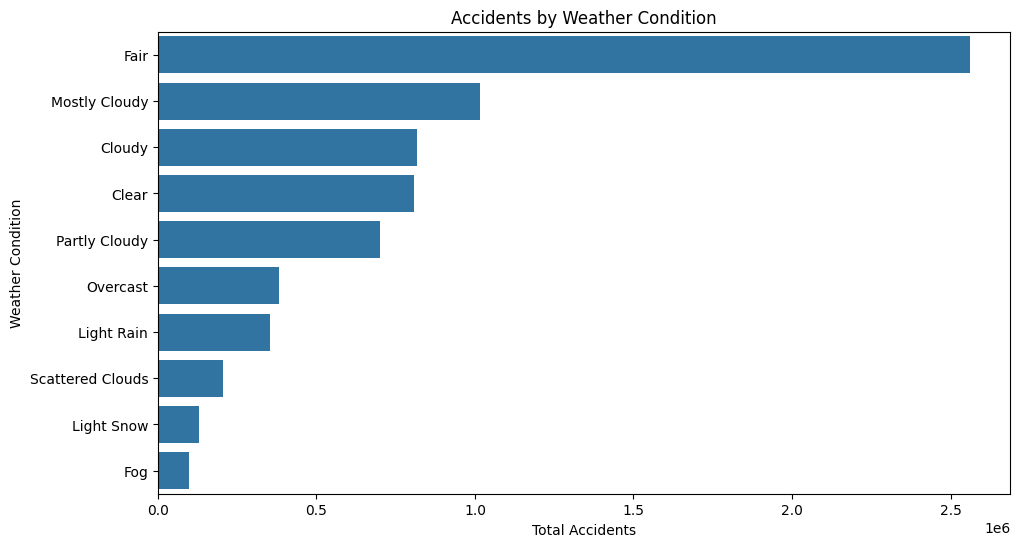

In [20]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=df_acc_weather,
    x="total_accidents",
    y="Weather_Condition"
)

plt.title("Accidents by Weather Condition")
plt.xlabel("Total Accidents")
plt.ylabel("Weather Condition")

plt.show()

In [21]:
# Time of Accidents
con.sql("""
SELECT EXTRACT(HOUR FROM Start_Time) AS accident_hour,
       COUNT(*) AS total_accidents
FROM accidents
GROUP BY accident_hour
ORDER BY total_accidents DESC
LIMIT 10
""").df()

,accident_hour,total_accidents
0,7,587472
1,16,581969
2,8,577576
3,17,576015
4,15,525855
5,14,448846
6,18,432042
7,6,405837
8,13,396445
9,9,363034


In [22]:
df_acc_time=con.sql("""
SELECT EXTRACT(HOUR FROM Start_Time) AS accident_hour,
       COUNT(*) AS total_accidents
FROM accidents
GROUP BY accident_hour
ORDER BY total_accidents DESC
LIMIT 10
""").df()

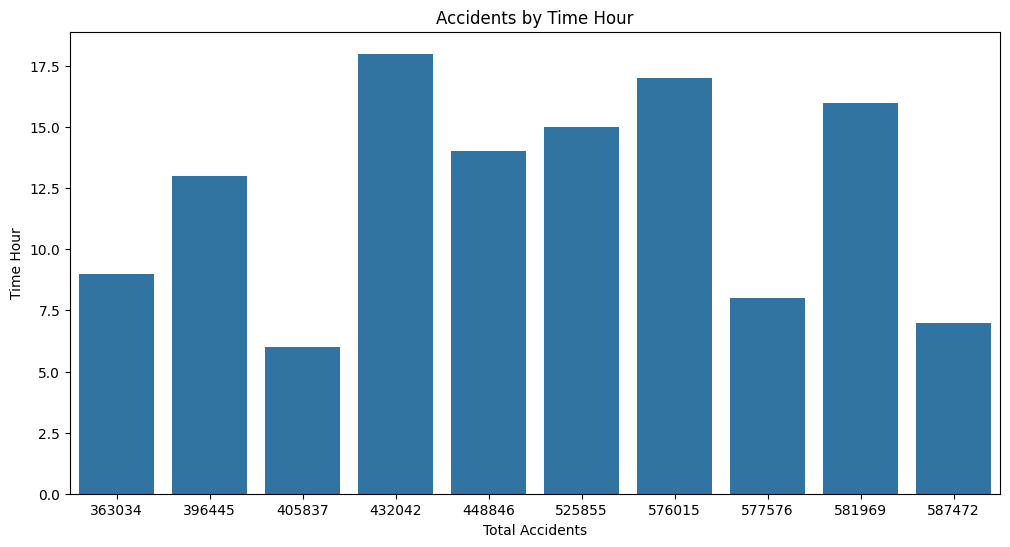

In [23]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_acc_time,
    x="total_accidents",
    y="accident_hour"
)

plt.title("Accidents by Time Hour")
plt.xlabel("Total Accidents")
plt.ylabel("Time Hour")

plt.show()

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

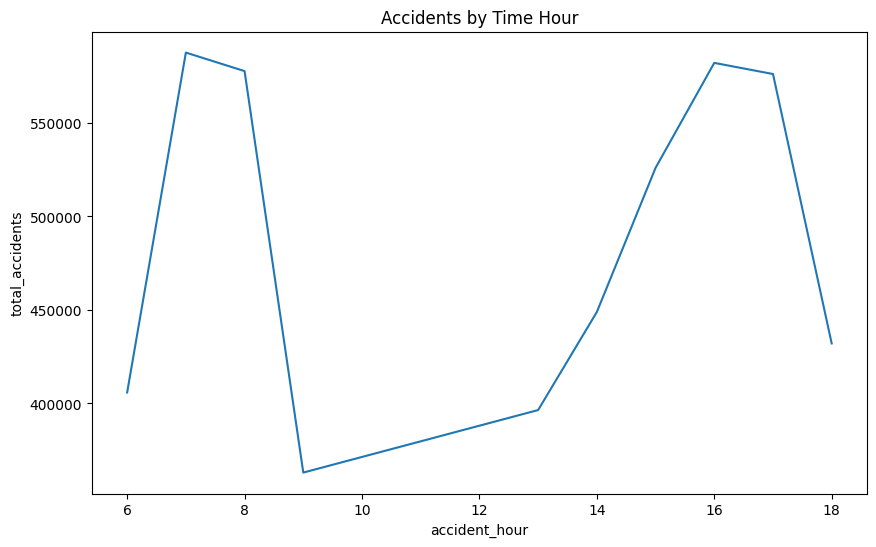

In [25]:


# Create a single line plot
plt.figure(figsize=(10, 6)) # Optional: set figure size
sns.lineplot(data=df_acc_time, y="total_accidents", x="accident_hour")
plt.title("Accidents by Time Hour") # Add a title
plt.show()


In [72]:
# Accidents rates are higher during working hours

In [26]:
# Days of Accidents
con.sql("""
SELECT CASE strftime('%w', Start_Time)
           WHEN '0' THEN 'Sunday'
           WHEN '1' THEN 'Monday'
           WHEN '2' THEN 'Tuesday'
           WHEN '3' THEN 'Wednesday'
           WHEN '4' THEN 'Thursday'
           WHEN '5' THEN 'Friday'
           WHEN '6' THEN 'Saturday'
       END AS weekday,
       COUNT(*) AS total_accidents
FROM accidents
GROUP BY weekday
ORDER BY total_accidents DESC
LIMIT 10
""").df()

,weekday,total_accidents
0,Friday,1366499
1,Thursday,1316229
2,Wednesday,1312389
3,Tuesday,1290929
4,Monday,1210921
5,Saturday,668683
6,Sunday,562744


In [115]:
df_acc_days=con.sql("""
SELECT CASE strftime('%w', Start_Time)
           WHEN '0' THEN 'Sunday'
           WHEN '1' THEN 'Monday'
           WHEN '2' THEN 'Tuesday'
           WHEN '3' THEN 'Wednesday'
           WHEN '4' THEN 'Thursday'
           WHEN '5' THEN 'Friday'
           WHEN '6' THEN 'Saturday'
       END AS weekday,
       COUNT(*) AS total_accidents
FROM accidents
GROUP BY weekday
ORDER BY total_accidents DESC
LIMIT 10
""").df()

In [27]:
# Accidents Severity per State
con.sql("""
SELECT State,
       ROUND(AVG(Severity), 2) AS avg_severity,
       COUNT(*) AS total_accidents
FROM accidents
GROUP BY State
HAVING COUNT(*) >= 1000
ORDER BY avg_severity DESC
LIMIT 10
""").df()

,State,avg_severity,total_accidents
0,GA,2.51,169234
1,WI,2.47,34688
2,RI,2.46,16971
3,KY,2.45,32254
4,CO,2.44,90885
5,IA,2.42,26307
6,MO,2.40,77323
7,IN,2.40,67224
8,IL,2.38,168958
9,NM,2.37,10325


In [28]:
# Accidents per Month
con.sql("""
SELECT EXTRACT(MONTH FROM Start_Time) AS accident_month,
       COUNT(*) AS total_accidents
FROM accidents
GROUP BY accident_month
ORDER BY total_accidents DESC
LIMIT 10
""").df()

,accident_month,total_accidents
0,12,847343
1,11,760165
2,1,751946
3,10,675130
4,2,658984
5,9,651381
6,8,599666
7,4,587300
8,6,571373
9,5,558176


In [82]:
df_acc_month=con.sql("""
SELECT EXTRACT(MONTH FROM Start_Time) AS accident_month,
       COUNT(*) AS total_accidents
FROM accidents
GROUP BY accident_month
ORDER BY total_accidents DESC
LIMIT 10
""").df()


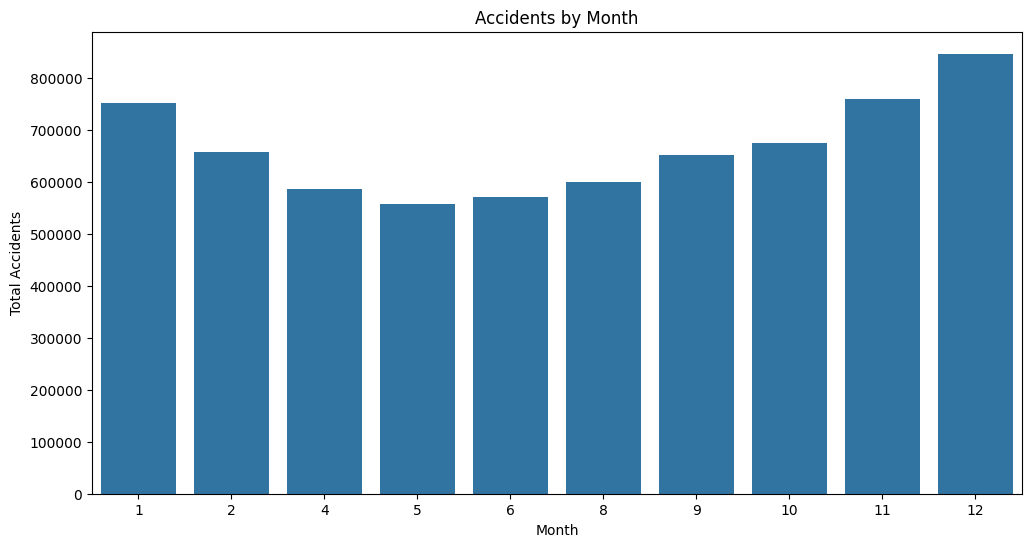

In [86]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_acc_month,
    y="total_accidents",
    x="accident_month"
)

plt.title("Accidents by Month")
plt.ylabel("Total Accidents")
plt.xlabel("Month")

plt.show()

In [88]:
# December, November and January have the highest number of total accidents

In [125]:
# What percentage of accidents happened in bad weather?
con.sql("""
SELECT 
    COUNT(*) AS total_accidents,
    SUM(CASE 
            WHEN Weather_Condition IN ('Rain', 'Heavy Rain', 'Snow', 'Heavy Snow', 'Fog', 'Thunderstorm')
            THEN 1 ELSE 0
        END) AS bad_weather_accidents,
    ROUND(
        100.0 * SUM(CASE 
                        WHEN Weather_Condition IN ('Rain', 'Heavy Rain', 'Snow', 'Heavy Snow', 'Fog', 'Thunderstorm')
                        THEN 1 ELSE 0
                    END) / COUNT(*),
        2
    ) AS bad_weather_percentage
FROM accidents;
""").df()

,total_accidents,bad_weather_accidents,bad_weather_percentage
0,7728394,240856.0,3.12


In [30]:
# Are accidents more common near traffic signals, junctions, or crossings?
con.sql("""
SELECT
    SUM(CASE WHEN Traffic_Signal = TRUE OR Traffic_Signal = 1 THEN 1 ELSE 0 END) AS near_traffic_signal,
    SUM(CASE WHEN Junction = TRUE OR Junction = 1 THEN 1 ELSE 0 END) AS near_junction,
    SUM(CASE WHEN Crossing = TRUE OR Crossing = 1 THEN 1 ELSE 0 END) AS near_crossing
FROM accidents;
""").df()

,near_traffic_signal,near_junction,near_crossing
0,1143772.0,571342.0,873763.0


In [96]:
# Top 10 Zipcode with more accidents
con.sql("""
SELECT Zipcode, City,State, COUNT(*) AS total_accidents
FROM accidents
WHERE Zipcode IS NOT NULL
GROUP BY Zipcode, City, State
ORDER BY total_accidents DESC
LIMIT 10;
""").df()

,Zipcode,City,State,total_accidents
0,91761,Ontario,CA,11247
1,91706,Baldwin Park,CA,10022
2,92407,San Bernardino,CA,8922
3,92507,Riverside,CA,8850
4,33186,Miami,FL,8375
5,32819,Orlando,FL,7461
6,91765,Diamond Bar,CA,7377
7,33169,Miami,FL,7105
8,90023,Los Angeles,CA,7066
9,92324,Colton,CA,7009


In [123]:
df.to_csv('accidents_usa.csv', index=False)